In [4]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.timeseries import LombScargle

def _bin_series_fixed_width(x, y, width):
    if not np.isfinite(width) or width <= 0:
        return np.array([]), np.array([])
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    mask = np.isfinite(x_arr) & np.isfinite(y_arr)
    if not mask.any():
        return np.array([]), np.array([])
    x_valid = x_arr[mask]
    y_valid = y_arr[mask]
    x_min = np.nanmin(x_valid)
    x_max = np.nanmax(x_valid)
    if not np.isfinite(x_min) or not np.isfinite(x_max):
        return np.array([]), np.array([])
    if x_min == x_max:
        edges = np.array([x_min, x_min + width])
    else:
        edges = np.arange(x_min, x_max + width, width)
        if edges.size < 2:
            edges = np.array([x_min, x_max])
    return _bin_series_by_edges(x_valid, y_valid, edges)

def _bin_series_by_edges(x, y, edges):
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    mask = np.isfinite(x_arr) & np.isfinite(y_arr)
    if not mask.any():
        return np.array([]), np.array([])
    x_valid = x_arr[mask]
    y_valid = y_arr[mask]
    inds = np.digitize(x_valid, edges) - 1
    valid = (inds >= 0) & (inds < len(edges) - 1)
    if not valid.any():
        return np.array([]), np.array([])
    x_valid = x_valid[valid]
    y_valid = y_valid[valid]
    inds = inds[valid]
    centers = []
    values = []
    for idx in np.unique(inds):
        bin_mask = inds == idx
        if np.any(bin_mask):
            centers.append(0.5 * (edges[idx] + edges[idx + 1]))
            values.append(np.nanmean(y_valid[bin_mask]))
    return np.array(centers), np.array(values)


period in days =  20.0


NameError: name 'figure' is not defined

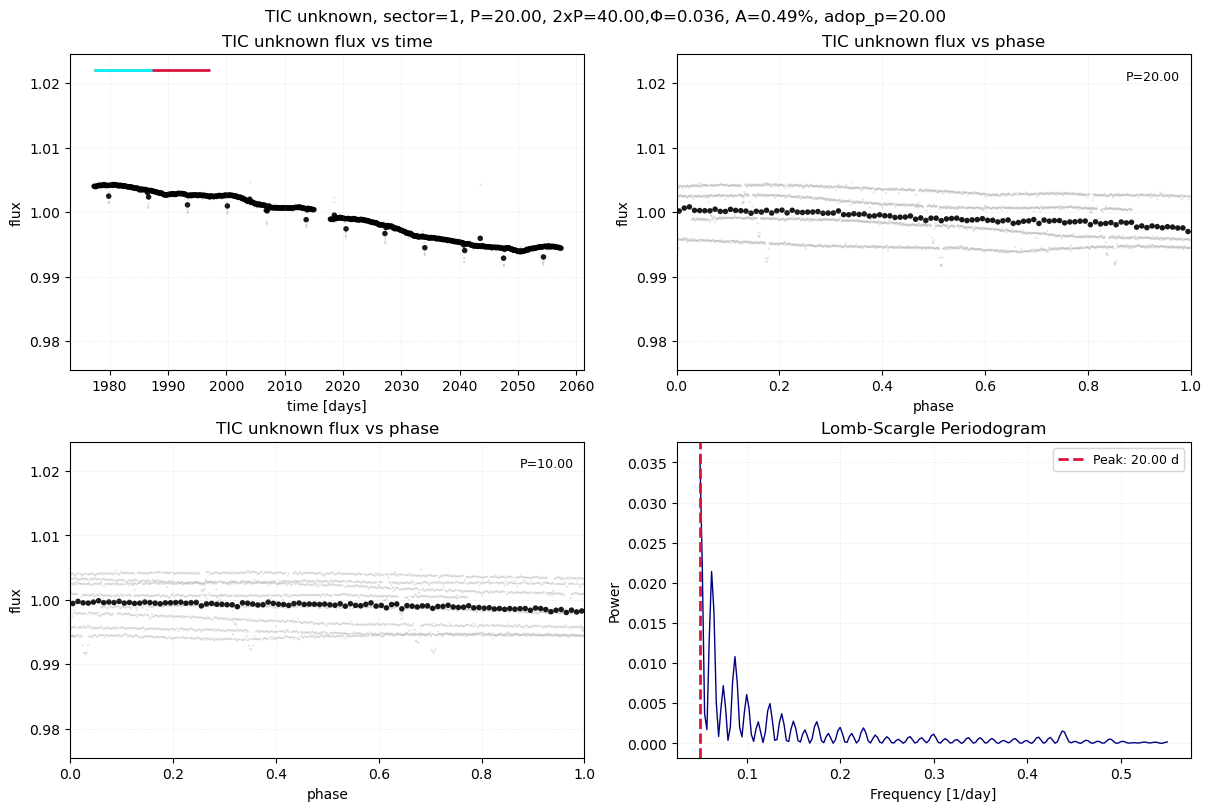

In [15]:
import matplotlib.pyplot as plt
import lightkurve as lk
from pdmpy import pdm

file = '/Users/iansterrett/Downloads/hlsp_k2sff_k2_lightcurve_201546283-c01_kepler_v1_llc.fits'
    
lc = lk.read(file)
ticid = lc.meta.get("TICID", "unknown")
finite = np.isfinite(lc.flux.value)
f = lc.flux.value[finite]

amp = 0.5 * (np.nanpercentile(f, 95) - np.nanpercentile(f, 5))

time, flux = lc.time.value, lc.flux.value

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax_time = axes[0, 0]
ax_phase = axes[0, 1]
ax_two_phase = axes[1, 0]
ax_periodogram = axes[1, 1]


def _get_flux_ylim(best_amp_val, flux_vals):
    if np.isfinite(best_amp_val) and best_amp_val > 0:
        return (1 - 5 * best_amp_val, 1 + 5 * best_amp_val)
    finite_flux = flux_vals[np.isfinite(flux_vals)]
    if finite_flux.size:
        f_med = np.nanmedian(finite_flux)
        f_std = np.nanstd(finite_flux)
        if not np.isfinite(f_std) or f_std == 0:
            f_std = 0.1 * abs(f_med) if f_med else 1.0
        return (f_med - 5 * f_std, f_med + 5 * f_std)
    return None

ax_time.scatter(time, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
bin_width_days = 4.0 / 24.0
binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
if binned_time.size:
    ax_time.scatter(
        binned_time,
        binned_flux,
        s=16,
        color="k",
        alpha=0.9,
        edgecolor="none",
        linewidths=0,
    )
ax_time.set_xlabel("time [days]")
ax_time.set_ylabel("flux")
ax_time.set_title(f"TIC {ticid} flux vs time")
ax_time.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
ylims_time = _get_flux_ylim(amp, flux)
ax_time.set_ylim(ylims_time)


frequency, power = LombScargle(time, flux).autopower(minimum_frequency = 1/20, maximum_frequency = 0.55)  # just chose frequency range manually

# extracting the period 
sector = 1

max_power_index = np.argmax(power)

max_frequency = frequency[max_power_index]

period = 1 / max_frequency

print("period in days = ", period)

star_period = period
ylims_phase = _get_flux_ylim(amp, flux)
star_power = np.max(power)
adopted_period = star_period

if np.isfinite(period) and period > 0:
    time0 = np.nanmin(time)
    phase = np.mod(time - time0, period) / period
    ax_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    phase_edges = np.linspace(0, 1, 101)
    binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
    if binned_phase.size:
        ax_phase.scatter(
            binned_phase,
            binned_phase_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_phase.set_xlim(0, 1)
    ax_phase.text(
        0.98,
        0.95,
        f"P={period:.2f}",
        transform=ax_phase.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="k",
    )
    if ylims_phase:
        ax_phase.set_ylim(ylims_phase)
    if ylims_time:
        y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
    else:
        y_line = ax_time.get_ylim()[1]
    x_start = np.nanmin(time)
    x_end = x_start + period
    ax_time.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2, zorder=5)
else:
    ax_phase.text(
        0.5,
        0.5,
        "No valid first_period",
        ha="center",
        va="center",
        transform=ax_phase.transAxes,
    )
    if ylims_phase:
        ax_phase.set_ylim(ylims_phase)
ax_phase.set_xlabel("phase")
ax_phase.set_ylabel("flux")
ax_phase.set_title(f"TIC {ticid} flux vs phase")
ax_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)

period = 0.5*star_period
ylims_phase = _get_flux_ylim(amp, flux)
if np.isfinite(period) and period > 0:
    time0 = np.nanmin(time)
    phase = np.mod(time - time0, period) / period
    ax_two_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    phase_edges = np.linspace(0, 1, 101)
    binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
    if binned_phase.size:
        ax_two_phase.scatter(
            binned_phase,
            binned_phase_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_two_phase.set_xlim(0, 1)
    ax_two_phase.text(
        0.98,
        0.95,
        f"P={period:.2f}",
        transform=ax_two_phase.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="k",
    )
    if ylims_phase:
        ax_two_phase.set_ylim(ylims_phase)
    if ylims_time:
        y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
    else:
        y_line = ax_time.get_ylim()[1]

    x_start = np.nanmin(time)
    x_end = x_start + period
    ax_time.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2, zorder=10)
    #ax_time.hlines(y_line, x_start, x_end, colors="", linewidth=2)
else:
    ax_two_phase.text(
        0.5,
        0.5,
        "No valid first_period",
        ha="center",
        va="center",
        transform=ax_two_phase.transAxes,
    )
    if ylims_phase:
        ax_two_phase.set_ylim(ylims_phase)
ax_two_phase.set_xlabel("phase")
ax_two_phase.set_ylabel("flux")
ax_two_phase.set_title(f"TIC {ticid} flux vs phase")
ax_two_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)


    ####
    
# ax_zoom.scatter(time, flux, s=2, color="0.7", alpha=1, edgecolor="none")
# bin_width_days = 4.0 / 24.0
# binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
# if binned_time.size:
#     ax_zoom.scatter(
#         binned_time,
#         binned_flux,
#         s=16,
#         color="k",
#         alpha=0.9,
#         edgecolor="none",
#         linewidths=0,
#     )
# ax_zoom.set_xlabel("time [days]")
# ax_zoom.set_ylabel("flux")
# ax_zoom.set_title(f"TIC {ticid} flux vs time")
# ax_zoom.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
# ylims_time = _get_flux_ylim(amp, flux)
# ax_zoom.set_ylim(ylims_time)
# ax_zoom.set_xlim(time[0], time[0] + 1)

# x_end = np.nanmax(time[0] + 1)
# x_start = x_end - 2*star_period
# ax_zoom.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2)

# x_start = np.nanmax(time[0])
# x_end = x_start + star_period
# ax_zoom.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2)

ax_periodogram.plot(frequency, power, color='navy', linewidth=1)
ax_periodogram.axvline(max_frequency, color='crimson', linestyle='--', linewidth=2, label=f'Peak: {adopted_period:.2f} d')
ax_periodogram.set_xlabel("Frequency [1/day]")
ax_periodogram.set_ylabel("Power")
ax_periodogram.set_title("Lomb-Scargle Periodogram")
ax_periodogram.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
ax_periodogram.legend(loc='best', fontsize=9)


fig.suptitle(
    f"TIC {ticid}, sector={sector}, P={star_period:.2f}, 2xP={2*star_period:.2f},Φ={star_power:.3f}, A={amp * 100:.2f}%, adop_p={adopted_period:.2f}",
    fontsize=12,
)

plt.savefig(figure, dpi=300, bbox_inches='tight')

plt.close()